In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [9]:
df = pd.read_csv('bank.csv', sep=',')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 1 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                      --------------  ----- 
 0   age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit  11162 non-null  object
dtypes: object(1)
memory usage: 87.3+ KB


In [5]:
df.describe()

,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
count,11162
unique,11162
top,"34,technician,married,secondary,no,0,no,no,cel..."
freq,1


In [6]:
df.shape

(11162, 1)

In [10]:
y = df['deposit']
display(y.head())

,deposit
0,yes
1,yes
2,yes
3,yes
4,yes


In [11]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [13]:
conversion_rate = (y=='yes').mean()*100
print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 47.38%


In [14]:
contacts = len(df)
contacts

11162

In [15]:
leads = len(df[df['poutcome']=='success'])
leads

1071

In [17]:
customers = len(y[y=='yes'])
customers

5289

In [19]:
customers = len(y[y=='yes'])
customers

5289

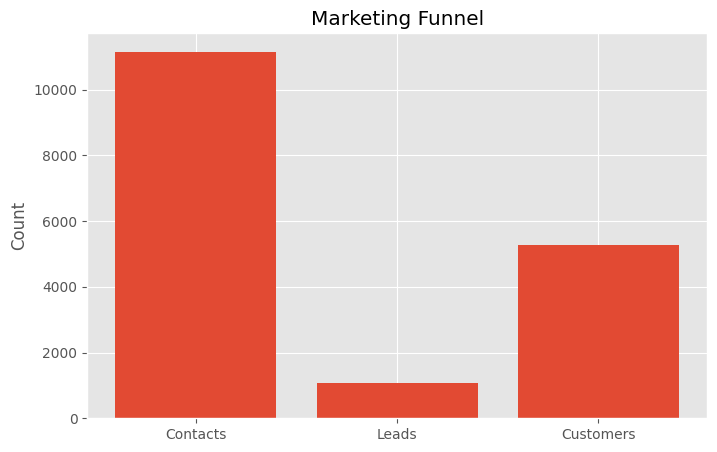

In [45]:
stages = ['Contacts','Leads','Customers']
values = [contacts, leads, customers]

plt.figure(figsize=(8,5))
plt.bar(stages, values)
plt.title('Marketing Funnel')
plt.ylabel('Count')
plt.savefig('Marketing_Funnel.png') # Save the plot
plt.show()

In [21]:
lead_conversion = leads/contacts*100
customer_conversion = customers/leads*100

print("Contact → Lead:", round(lead_conversion,2),"%")
print("Lead → Customer:", round(customer_conversion,2),"%")

Contact → Lead: 9.6 %
Lead → Customer: 493.84 %


In [23]:
channel_perf = pd.crosstab(df['contact'],y)

channel_perf

deposit,no,yes
contact,,
cellular,3673,4369
telephone,384,390
unknown,1816,530


In [25]:
channel_rate = y.groupby(df['contact']).apply(
lambda x:(x=='yes').mean()*100)

channel_rate.sort_values(ascending=False)

,deposit
contact,
cellular,54.327282
telephone,50.387597
unknown,22.591645


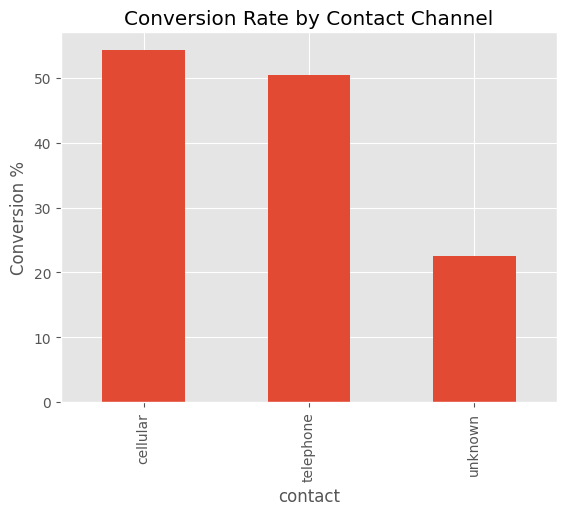

In [46]:
channel_rate.plot(kind='bar')
plt.title('Conversion Rate by Contact Channel')
plt.ylabel('Conversion %')
plt.savefig('Conversion_Rate_by_Contact_Channel.png') # Save the plot
plt.show()

In [28]:
campaign_rate = y.groupby(df['campaign']).apply(
lambda x:(x=='yes').mean()*100)

campaign_rate.head()

,deposit
campaign,
1,53.376407
2,46.268164
3,46.782740
4,41.115435
5,36.772487


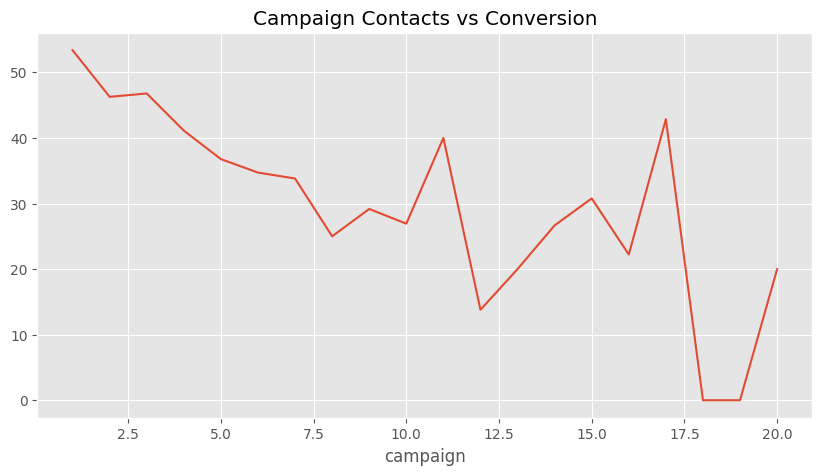

In [47]:
campaign_rate.head(20).plot(figsize=(10,5))
plt.title('Campaign Contacts vs Conversion')
plt.savefig('Campaign_Contacts_vs_Conversion.png') # Save the plot
plt.show()

In [31]:
job_rate = y.groupby(df['job']).apply(
lambda x:(x=='yes').mean()*100)

job_rate.sort_values(ascending=False)

,deposit
job,
student,74.722222
retired,66.323907
unemployed,56.582633
management,50.701481
unknown,48.571429
admin.,47.301349
self-employed,46.172840
technician,46.077894
services,39.978332


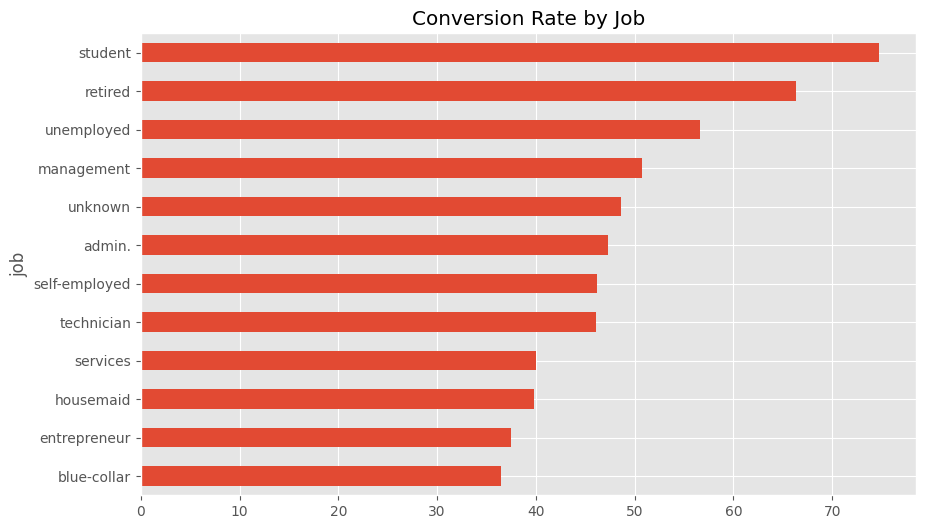

In [48]:
job_rate.sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Conversion Rate by Job')
plt.savefig('Conversion_Rate_by_Job.png') # Save the plot
plt.show()

In [33]:
df['Age_Group'] = pd.cut(
df['age'],
bins=[18,30,45,60,100],
labels=['18-30','31-45','46-60','60+']
)

In [35]:
age_rate = y.groupby(df['Age_Group']).apply(
lambda x:(x=='yes').mean()*100)

age_rate

/tmp/ipykernel_965/3920638476.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = y.groupby(df['Age_Group']).apply(


,deposit
Age_Group,
18-30,56.928464
31-45,42.466498
46-60,42.918597
60+,82.160393


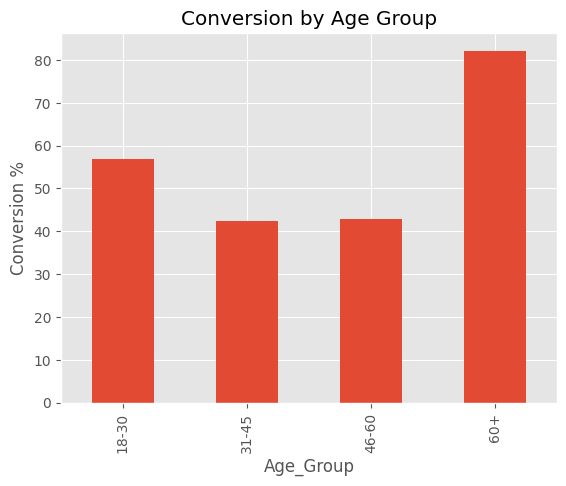

In [49]:
age_rate.plot(kind='bar')
plt.title('Conversion by Age Group')
plt.ylabel('Conversion %')
plt.savefig('Conversion_by_Age_Group.png') # Save the plot
plt.show()

In [37]:
drop1 = contacts - leads
drop2 = leads - customers

print("Contact → Lead Drop:", drop1)
print("Lead → Customer Drop:", drop2)

Contact → Lead Drop: 10091
Lead → Customer Drop: -4218


In [42]:
import os

for file in os.listdir():
    if file.endswith('.png'):
        print(file)

downloaded_image.png


In [50]:
import os
from google.colab import files

image_files = [
    'Marketing_Funnel.png',
    'Conversion_Rate_by_Contact_Channel.png',
    'Campaign_Contacts_vs_Conversion.png',
    'Conversion_by_Age_Group.png',
    'Conversion_Rate_by_Job.png'
]

for image in image_files:
    if os.path.exists(image):
        files.download(image)
    else:
        print(f"Warning: File '{image}' not found. Please ensure it has been saved in a previous cell (e.g., using plt.savefig()).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>